<a href="https://colab.research.google.com/github/BreakPaw/animal_classifier/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !unzip -q animalfacemodel.zip -d /content/
# print("Ekstraksi file animalfacemodel selesai!")

In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [3]:
image_path = []
labels = []

for i in os.listdir("afhq"):
  for label in os.listdir(f"afhq/{i}"):
    for image in os.listdir(f"afhq/{i}/{label}"):
      image_path.append(f"afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['dog' 'wild' 'cat']


,image_path,labels
0,afhq/train/dog/pixabay_dog_001616.jpg,dog
1,afhq/train/dog/pixabay_dog_002255.jpg,dog
2,afhq/train/dog/flickr_dog_000195.jpg,dog
3,afhq/train/dog/pixabay_dog_001925.jpg,dog
4,afhq/train/dog/pixabay_dog_001299.jpg,dog


In [4]:
# train = data_df.sample(frac = 0.7)
# test = data_df.drop(train.index)

# val = test.sample(frac = 0.5)
# test = test.drop(val.index)

# print(train.shape, test.shape, val.shape)
# Mengatur porsi 80% Train, 10% Val, 10% Test
train = data_df.sample(frac = 0.8, random_state=42)
test_val_temp = data_df.drop(train.index)

val = test_val_temp.sample(frac = 0.5, random_state=42)
test = test_val_temp.drop(val.index)

print(train.shape, test.shape, val.shape)

(12904, 2) (1613, 2) (1613, 2)


In [5]:
# label_encoder = LabelEncoder()
# label_encoder.fit(data_df["labels"])

# transform = transforms.Compose([
#     transforms.Resize((128,128)),
#     transforms.ToTensor(),
#     transforms.ConvertImageDtype(torch.float)
# ])
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

# Transformasi dengan Augmentasi HANYA untuk Data Latih
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(), # Mencegah overfitting
    transforms.RandomRotation(10),     # Mencegah overfitting
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [6]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [7]:
# train_dataset = CustomImageDataset(dataframe = train, transform = transform)
# test_dataset = CustomImageDataset(dataframe = test, transform = transform)
# val_dataset = CustomImageDataset(dataframe = val, transform = transform)

# Transformasi biasa untuk Data Validasi dan Uji
test_val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

# Menerapkan transform yang berbeda
train_dataset = CustomImageDataset(dataframe = train, transform = train_transform)
test_dataset = CustomImageDataset(dataframe = test, transform = test_val_transform)
val_dataset = CustomImageDataset(dataframe = val, transform = test_val_transform)

In [8]:
print(train.iloc[2, 0])

afhq/train/cat/pixabay_cat_003653.jpg


In [9]:
train_dataset.__getitem__(2)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'),
 tensor(0, device='cuda:0'))

In [10]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

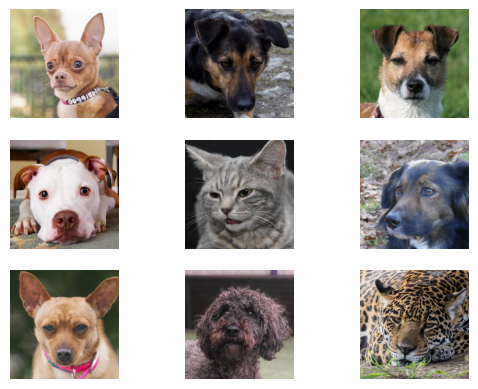

In [11]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [12]:
# LR = 1e-4
# BATCH_SIZE = 16
# EPOCHS = 10
LR = 1e-4
BATCH_SIZE = 32 # Dinaikkan menjadi 32
EPOCHS = 8      # Diturunkan untuk mencegah overfit di akhir

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [14]:
# class Net(nn.Module):
#   def __init__(self):
#     super().__init__()

#     self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding= 1)
#     self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding= 1)
#     self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding= 1)

#     self.pooling = nn.MaxPool2d(2, 2)

#     self.relu = nn.ReLU()

#     self.flatten = nn.Flatten()
#     self.linear = nn.Linear((128*16*16), 128)

#     self.output = nn.Linear(128, len(data_df['labels'].unique()))

#   def forward(self, x):
#     x = self.conv1(x)
#     x = self.pooling(x)
#     x = self.relu(x)

#     x = self.conv2(x)
#     x = self.pooling(x)
#     x = self.relu(x)

#     x = self.conv3(x)
#     x = self.pooling(x)
#     x = self.relu(x)

#     x = self.flatten(x)
#     x = self.linear(x)
#     x = self.output(x)

#     return x
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(32) # Tambahan BatchNorm

    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64) # Tambahan BatchNorm

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128) # Tambahan BatchNorm

    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.dropout = nn.Dropout(0.5) # Tambahan Dropout 50%

    self.linear = nn.Linear((128*16*16), 128)
    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    # Memasukkan BatchNorm setelah Konvolusi
    x = self.pooling(self.relu(self.bn1(self.conv1(x))))
    x = self.pooling(self.relu(self.bn2(self.conv2(x))))
    x = self.pooling(self.relu(self.bn3(self.conv3(x))))

    x = self.flatten(x)
    x = self.dropout(x) # Mengaktifkan dropout sebelum layer Linear
    x = self.relu(self.linear(x))
    x = self.output(x)

    return x

In [15]:
model = Net().to(device)

In [16]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
      BatchNorm2d-10          [-1, 128, 32, 32]             256
             ReLU-11          [-1, 128, 32, 32]               0
        MaxPool2d-12          [-1, 128, 16, 16]               0
          Flatten-13                [-1, 32768]               0
          Dropout-14                [-1

In [17]:
# criterion = nn.CrossEntropyLoss()
# optimizer = Adam(model.parameters(), lr = LR)
criterion = nn.CrossEntropyLoss()
# Menambahkan weight_decay untuk L2 Regularization
optimizer = Adam(model.parameters(), lr = LR, weight_decay=1e-4)

In [18]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f'''Epoch {epoch +1}/{EPOCHS},
            Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
            Validation Loss {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
        ''')

Epoch 1/8,
            Train Loss: 0.1276 Train Accuracy 87.5155
            Validation Loss 0.0079 Validation Accuracy 93.7384
        
Epoch 2/8,
            Train Loss: 0.0666 Train Accuracy 93.8546
            Validation Loss 0.0047 Validation Accuracy 96.3422
        
Epoch 3/8,
            Train Loss: 0.0523 Train Accuracy 95.0635
            Validation Loss 0.0051 Validation Accuracy 96.4662
        
Epoch 4/8,
            Train Loss: 0.0411 Train Accuracy 96.381
            Validation Loss 0.0038 Validation Accuracy 96.7762
        
Epoch 5/8,
            Train Loss: 0.039 Train Accuracy 96.4817
            Validation Loss 0.0043 Validation Accuracy 97.4582
        
Epoch 6/8,
            Train Loss: 0.033 Train Accuracy 97.0397
            Validation Loss 0.0038 Validation Accuracy 97.0862
        
Epoch 7/8,
            Train Loss: 0.0296 Train Accuracy 97.3342
            Validation Loss 0.0034 Validation Accuracy 97.5821
        
Epoch 8/8,
            Train Loss: 0.0271 Tr

In [19]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")


Accuracy Score is: 97.0862 and Loss is 0.0044


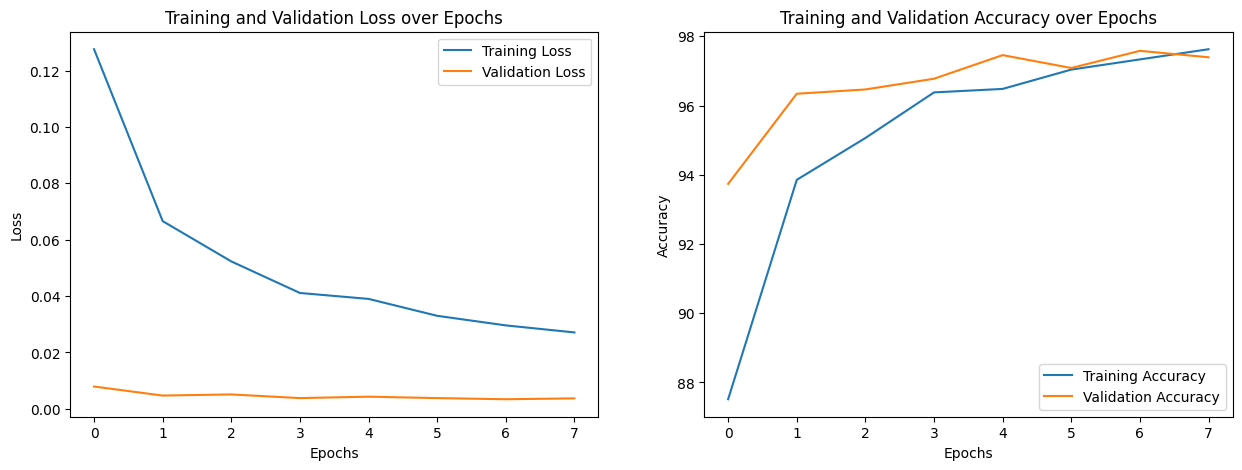

In [20]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [23]:
def predict_image(image_path):
  # Menggunakan variabel image_path tanpa tanda kutip
  image = Image.open(image_path).convert('RGB')

  # GANTI 'transform' menjadi 'test_val_transform'
  image = test_val_transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [24]:
predict_image("afhq/train/wild/flickr_wild_000002.jpg")

array(['wild'], dtype=object)

In [25]:
# 1. Install gradio
!pip install gradio --quiet
import gradio as gr
import torch

# 2. Buat fungsi khusus untuk website
def predict_web(image):
    # Memastikan gambar dalam format RGB
    image = image.convert('RGB')

    # Menerapkan transformasi yang sama dengan data testing
    image_tensor = test_val_transform(image).to(device)

    # Lakukan prediksi
    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0))
        output_idx = torch.argmax(output, axis=1).item()

    # Mengembalikan nama label hewan
    predicted_label = label_encoder.inverse_transform([output_idx])[0]

    # Ubah format teks agar lebih rapi di website
    if predicted_label == 'cat':
        return "Kucing 🐱"
    elif predicted_label == 'dog':
        return "Anjing 🐶"
    else:
        return "Hewan Liar 🦁"

# 3. Buat dan luncurkan website
demo = gr.Interface(
    fn=predict_web,                           # Fungsi yang dipanggil
    inputs=gr.Image(type="pil"),              # Input berupa unggahan gambar
    outputs=gr.Text(label="Hasil Prediksi"),  # Output berupa teks
    title="Klasifikasi Wajah Hewan AI",
    description="Unggah gambar wajah kucing, anjing, atau hewan liar, dan biarkan AI menebaknya!"
)

# Meluncurkan website dan membuat link publik
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3f86b0ced849b734c4.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
